# Sentiment Inference API — Demo Notebook

This notebook demonstrates the deployed sentiment classification API.

**Prerequisites**
- The stack is running via `docker compose up` from `ml-api-demo/`.
- The API is reachable at `http://localhost` (nginx publishes port 80; the API and frontend are only accessible inside the docker network).

**What this notebook covers**
1. Health check
2. Single predictions on positive and negative examples
3. Parallel load test (50 concurrent requests through a thread pool)
4. Edge cases (empty input, oversize input, malformed JSON, batch input)
5. Summary


In [1]:
import json
import statistics
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import requests
from IPython.display import Markdown, display

BASE_URL = "http://localhost/api"
TIMEOUT = 30  # seconds


## Section 1: Health Check

The `/health` endpoint reports whether the model is loaded and ready. We assert `model_loaded` is `True` so the rest of the notebook can rely on the service being up.

In [2]:
response = requests.get(f"{BASE_URL}/health", timeout=TIMEOUT)
response.raise_for_status()
health = response.json()
print(json.dumps(health, indent=2))
assert health["model_loaded"] is True, "Model is not loaded; abort the rest of the notebook."


{
  "status": "ok",
  "model_loaded": true,
  "model": "distilbert-base-uncased-finetuned-sst-2-english"
}


## Section 2: Single Prediction

In [3]:
positive_input = "I love this product, it works exactly as described."
response = requests.post(
    f"{BASE_URL}/predict",
    json={"text": positive_input},
    timeout=TIMEOUT,
)
response.raise_for_status()
result = response.json()
prediction = result["predictions"][0]
print(f"Input:        {positive_input}")
print(f"Label:        {prediction['label']}")
print(f"Score:        {prediction['score']:.4f}")
print(f"Inference ms: {result['inference_ms']:.2f}")


Input:        I love this product, it works exactly as described.
Label:        POSITIVE
Score:        0.9999
Inference ms: 133.70


In [4]:
negative_input = "Worst purchase I've made all year, complete waste of money."
response = requests.post(
    f"{BASE_URL}/predict",
    json={"text": negative_input},
    timeout=TIMEOUT,
)
response.raise_for_status()
result = response.json()
prediction = result["predictions"][0]
print(f"Input:        {negative_input}")
print(f"Label:        {prediction['label']}")
print(f"Score:        {prediction['score']:.4f}")
print(f"Inference ms: {result['inference_ms']:.2f}")


Input:        Worst purchase I've made all year, complete waste of money.
Label:        NEGATIVE
Score:        0.9998
Inference ms: 56.27


## Section 3: Parallel Load Test

The deployed FastAPI service runs behind gunicorn with multiple workers (four by default). To demonstrate concurrent handling, we fire 50 requests in parallel using a thread pool with 10 worker threads and measure end-to-end latencies.

In [5]:
SHORT_POSITIVE = [
    "Great service!",
    "Loved every minute.",
    "Highly recommend.",
    "Best decision I made.",
    "Fantastic experience.",
]
SHORT_NEGATIVE = [
    "Terrible. Never again.",
    "Hated it.",
    "Wouldn't recommend.",
    "Complete disappointment.",
    "Don't waste your money.",
]
MEDIUM = [
    "The customer service was incredibly helpful, friendly, and patient throughout the entire process.",
    "I'm extremely disappointed with the build quality and overall design of this product.",
    "This is hands down the best meal I've had in months — every bite was a delight.",
    "Waited an hour for cold food and rude staff; I will never come back.",
    "Solid performance for the price point; nothing extraordinary but reliable.",
]
TEST_INPUTS = (SHORT_POSITIVE + SHORT_NEGATIVE + MEDIUM) * 4
TEST_INPUTS = TEST_INPUTS[:50]
print(f"prepared {len(TEST_INPUTS)} inputs")


def time_request(text: str):
    """POST /predict and return (latency_seconds, status_code, response_body_or_None)."""
    start = time.perf_counter()
    try:
        resp = requests.post(
            f"{BASE_URL}/predict",
            json={"text": text},
            timeout=TIMEOUT,
        )
        elapsed = time.perf_counter() - start
        try:
            body = resp.json()
        except ValueError:
            body = None
        return elapsed, resp.status_code, body
    except requests.RequestException as exc:
        return time.perf_counter() - start, 0, {"error": str(exc)}


prepared 50 inputs


In [6]:
overall_start = time.perf_counter()
results = []
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = [executor.submit(time_request, text) for text in TEST_INPUTS]
    for fut in as_completed(futures):
        results.append(fut.result())
wall_clock = time.perf_counter() - overall_start

latencies_ms = [r[0] * 1000 for r in results]
successes = sum(1 for r in results if r[1] == 200)
success_rate = successes / len(results) * 100

# statistics.quantiles(n=100) returns 99 cut points (1st .. 99th percentile)
quantiles = statistics.quantiles(latencies_ms, n=100)
p50 = quantiles[49]
p95 = quantiles[94]
p99 = quantiles[98]

print(f"Total wall-clock: {wall_clock:.2f} s")
print(f"Success rate:     {success_rate:.1f}% ({successes}/{len(results)})")
print(f"Mean latency:     {statistics.mean(latencies_ms):.1f} ms")
print(f"Median (p50):     {statistics.median(latencies_ms):.1f} ms")
print(f"p50 (quantile):   {p50:.1f} ms")
print(f"p95:              {p95:.1f} ms")
print(f"p99:              {p99:.1f} ms")


Total wall-clock: 0.60 s
Success rate:     100.0% (50/50)
Mean latency:     112.0 ms
Median (p50):     105.7 ms
p50 (quantile):   105.7 ms
p95:              163.4 ms
p99:              187.6 ms


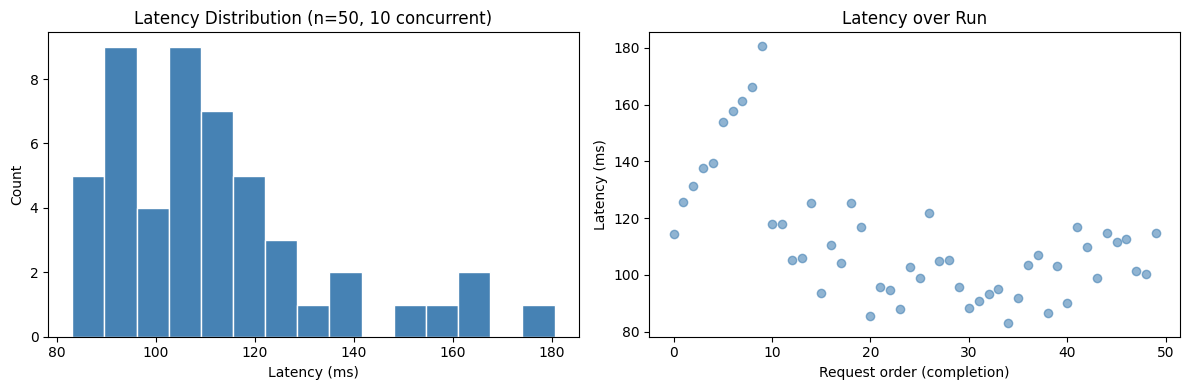

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(latencies_ms, bins=15, color="steelblue", edgecolor="white")
ax1.set_xlabel("Latency (ms)")
ax1.set_ylabel("Count")
ax1.set_title("Latency Distribution (n=50, 10 concurrent)")

ax2.scatter(range(len(latencies_ms)), latencies_ms, alpha=0.6, color="steelblue")
ax2.set_xlabel("Request order (completion)")
ax2.set_ylabel("Latency (ms)")
ax2.set_title("Latency over Run")

plt.tight_layout()
plt.show()


## Section 4: Edge Cases

Verify the API's input validation. Each subsection should return the expected status code without crashing the service.

In [8]:
resp = requests.post(f"{BASE_URL}/predict", json={"text": ""}, timeout=TIMEOUT)
print(f"Status: {resp.status_code}")
print(json.dumps(resp.json(), indent=2))
assert resp.status_code == 422, f"Expected 422, got {resp.status_code}"


Status: 422
{
  "detail": [
    {
      "type": "string_too_short",
      "loc": [
        "body",
        "text"
      ],
      "msg": "String should have at least 1 character",
      "input": "",
      "ctx": {
        "min_length": 1
      }
    }
  ]
}


In [9]:
long_text = "x" * 10000
resp = requests.post(f"{BASE_URL}/predict", json={"text": long_text}, timeout=TIMEOUT)
print(f"Status: {resp.status_code}")
print(f"Input length: {len(long_text)} chars")
body = resp.json()
print(json.dumps(body, indent=2)[:400])
assert resp.status_code == 422, f"Expected 422, got {resp.status_code}"


Status: 422
Input length: 10000 chars
{
  "detail": [
    {
      "type": "string_too_long",
      "loc": [
        "body",
        "text"
      ],
      "msg": "String should have at most 5000 characters",
      "input": "xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [10]:
resp = requests.post(
    f"{BASE_URL}/predict",
    data='{"text": "missing brace',  # malformed JSON
    headers={"Content-Type": "application/json"},
    timeout=TIMEOUT,
)
print(f"Status: {resp.status_code}")
try:
    print(json.dumps(resp.json(), indent=2))
except ValueError:
    print(resp.text[:400])
assert resp.status_code in (400, 422), f"Expected 400 or 422, got {resp.status_code}"


Status: 422
{
  "detail": [
    {
      "type": "json_invalid",
      "loc": [
        "body",
        9
      ],
      "msg": "JSON decode error",
      "input": {},
      "ctx": {
        "error": "Unterminated string starting at"
      }
    }
  ]
}


In [11]:
batch = {"texts": ["I love it", "I hate it", "It is okay"]}
resp = requests.post(f"{BASE_URL}/predict", json=batch, timeout=TIMEOUT)
resp.raise_for_status()
body = resp.json()
print(json.dumps(body, indent=2))
assert len(body["predictions"]) == 3, f"Expected 3 predictions, got {len(body['predictions'])}"


{
  "predictions": [
    {
      "label": "POSITIVE",
      "score": 0.9998799562454224
    },
    {
      "label": "NEGATIVE",
      "score": 0.9996395111083984
    },
    {
      "label": "POSITIVE",
      "score": 0.9998480081558228
    }
  ],
  "model": "distilbert-base-uncased-finetuned-sst-2-english",
  "inference_ms": 110.7058329944266
}


## Section 5: Summary

This notebook demonstrated:

- **Health endpoint** signals readiness via `/health`
- **Single predictions** return label, score, and inference latency
- **Parallel handling** through gunicorn workers; 50 requests at concurrency 10 — see the latency distribution and per-request scatter above
- **Pydantic validation** rejects empty strings, oversize inputs, and malformed JSON with a 422 response — no crashes
- **Batch endpoint** accepts a list of texts in one request for efficient bulk inference

The full latency distribution and per-request timing chart provide the quantitative numbers for any deployment review.
